# Thesis: Trading Volume and Bitcoin Volatility
## Rennes School of Business — Dr. Taoufik Bouraoui
## Python Code: Random Forest + LSTM
### Data: BTC_clean_for_python.csv (exported from R)

In [1]:
# CELL 1: Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print('Libraries loaded successfully.')
print(f'TensorFlow version: {tf.__version__}')

Libraries loaded successfully.
TensorFlow version: 2.19.0


In [2]:
# CELL 2: Load data

df = pd.read_csv('BTC_clean_for_python.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print('Shape:', df.shape)
print('Date range:', df['Date'].min(), 'to', df['Date'].max())
print('Columns:', df.columns.tolist())
print('Missing values:', df.isnull().sum().sum())
print(df.head(3))

Shape: (1992, 8)
Date range: 2019-07-20 00:00:00 to 2024-12-31 00:00:00
Columns: ['Date', 'Close', 'log_return', 'volatility', 'Volume_BTC', 'log_volume', 'MA200', 'regime']
Missing values: 0
        Date     Close  log_return  volatility   Volume_BTC  log_volume  \
0 2019-07-20  10740.23    0.022213    0.022213  47331.89985   10.764940   
1 2019-07-21  10589.45   -0.014138    0.014138  38834.28794   10.567059   
2 2019-07-22  10340.31   -0.023808    0.023808  40467.95484   10.608266   

        MA200  regime  
0  6093.18065       1  
1  6126.83510       1  
2  6159.70275       1  


In [3]:
# CELL 3: Prepare features
# Features: lagged volatility, lagged log volume, regime
# Target: current volatility

df['vol_lag1']    = df['volatility'].shift(1)
df['vol_lag2']    = df['volatility'].shift(2)
df['vol_lag3']    = df['volatility'].shift(3)
df['lvol_lag1']   = df['log_volume'].shift(1)
df['lvol_lag2']   = df['log_volume'].shift(2)
df['ret_lag1']    = df['log_return'].shift(1)
df['ret_lag2']    = df['log_return'].shift(2)

df = df.dropna().reset_index(drop=True)

features = ['vol_lag1', 'vol_lag2', 'vol_lag3',
            'lvol_lag1', 'lvol_lag2',
            'ret_lag1', 'ret_lag2',
            'log_volume', 'regime']

target = 'volatility'

X = df[features].values
y = df[target].values

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)
print('Features used:', features)

Feature matrix shape: (1989, 9)
Target shape: (1989,)
Features used: ['vol_lag1', 'vol_lag2', 'vol_lag3', 'lvol_lag1', 'lvol_lag2', 'ret_lag1', 'ret_lag2', 'log_volume', 'regime']


In [4]:
# CELL 4: Train/test split (80/20, time-ordered)
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f'Training set: {len(X_train)} observations')
print(f'Test set    : {len(X_test)} observations')
print(f'Split date  : {df["Date"].iloc[split].date()}')

Training set: 1591 observations
Test set    : 398 observations
Split date  : 2023-11-30


In [5]:
# CELL 5: RANDOM FOREST — Full Sample
rf_full = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_full.fit(X_train, y_train)
y_pred_rf_full = rf_full.predict(X_test)

rmse_rf_full = np.sqrt(mean_squared_error(y_test, y_pred_rf_full))
mae_rf_full  = mean_absolute_error(y_test, y_pred_rf_full)
r2_rf_full   = r2_score(y_test, y_pred_rf_full)

print('========== RANDOM FOREST — FULL SAMPLE ==========')
print(f'  RMSE : {rmse_rf_full:.6f}')
print(f'  MAE  : {mae_rf_full:.6f}')
print(f'  R²   : {r2_rf_full:.4f}')

# Feature importance
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_full.feature_importances_
}).sort_values('Importance', ascending=False)

print('\nFeature Importances:')
print(importances.to_string(index=False))

========== RANDOM FOREST — FULL SAMPLE ==========
  RMSE : 0.015875
  MAE  : 0.011299
  R²   : 0.2784

Feature Importances:
   Feature  Importance
log_volume    0.472441
 lvol_lag1    0.158256
  ret_lag1    0.064644
  vol_lag1    0.062949
 lvol_lag2    0.062149
  vol_lag3    0.060194
  vol_lag2    0.058571
  ret_lag2    0.053623
    regime    0.007174


In [6]:
# CELL 6: RANDOM FOREST — Bullish vs Bearish
df_bull = df[df['regime'] == 1].reset_index(drop=True)
df_bear = df[df['regime'] == 0].reset_index(drop=True)

def run_rf_regime(df_regime, label):
    X_r = df_regime[features].values
    y_r = df_regime[target].values
    split_r = int(len(X_r) * 0.8)
    X_tr, X_te = X_r[:split_r], X_r[split_r:]
    y_tr, y_te = y_r[:split_r], y_r[split_r:]

    rf = RandomForestRegressor(n_estimators=500, max_depth=10,
                               min_samples_split=5, random_state=42, n_jobs=-1)
    rf.fit(X_tr, y_tr)
    y_pred = rf.predict(X_te)

    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae  = mean_absolute_error(y_te, y_pred)
    r2   = r2_score(y_te, y_pred)

    imp = pd.DataFrame({'Feature': features,
                        'Importance': rf.feature_importances_
                       }).sort_values('Importance', ascending=False)

    print(f'\n========== RANDOM FOREST — {label} ==========')
    print(f'  N (total) : {len(X_r)}')
    print(f'  N (test)  : {len(X_te)}')
    print(f'  RMSE : {rmse:.6f}')
    print(f'  MAE  : {mae:.6f}')
    print(f'  R²   : {r2:.4f}')
    print('  Feature Importances:')
    print(imp.to_string(index=False))
    return rf, rmse, mae, r2, imp

rf_bull, rmse_bull, mae_bull, r2_bull, imp_bull = run_rf_regime(df_bull, 'BULLISH')
rf_bear, rmse_bear, mae_bear, r2_bear, imp_bear = run_rf_regime(df_bear, 'BEARISH')


========== RANDOM FOREST — BULLISH ==========
  N (total) : 1207
  N (test)  : 242
  RMSE : 0.015568
  MAE  : 0.010945
  R²   : 0.3483
  Feature Importances:
   Feature  Importance
log_volume    0.448874
 lvol_lag1    0.142725
 lvol_lag2    0.094984
  ret_lag1    0.075490
  vol_lag3    0.064663
  vol_lag1    0.064204
  vol_lag2    0.062291
  ret_lag2    0.046769
    regime    0.000000

========== RANDOM FOREST — BEARISH ==========
  N (total) : 782
  N (test)  : 157
  RMSE : 0.016164
  MAE  : 0.011910
  R²   : 0.0425
  Feature Importances:
   Feature  Importance
log_volume    0.424236
 lvol_lag1    0.185479
 lvol_lag2    0.086384
  ret_lag2    0.081931
  ret_lag1    0.062527
  vol_lag3    0.057041
  vol_lag2    0.054044
  vol_lag1    0.048357
    regime    0.000000


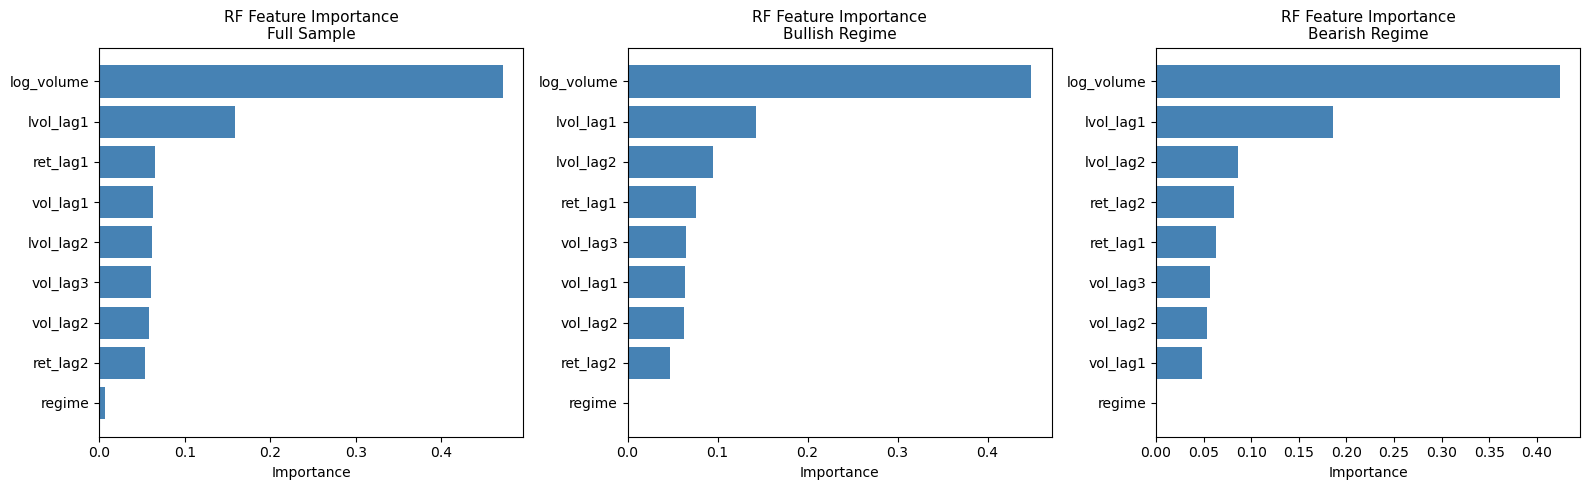

Plot saved as RF_feature_importance.png


In [7]:
# CELL 7: Feature Importance Plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

imp_full = pd.DataFrame({'Feature': features,
                         'Importance': rf_full.feature_importances_
                        }).sort_values('Importance', ascending=True)

for ax, imp_df, title in zip(
        axes,
        [imp_full,
         imp_bull.sort_values('Importance', ascending=True),
         imp_bear.sort_values('Importance', ascending=True)],
        ['Full Sample', 'Bullish Regime', 'Bearish Regime']):
    ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue')
    ax.set_title(f'RF Feature Importance\n{title}', fontsize=11)
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('RF_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as RF_feature_importance.png')

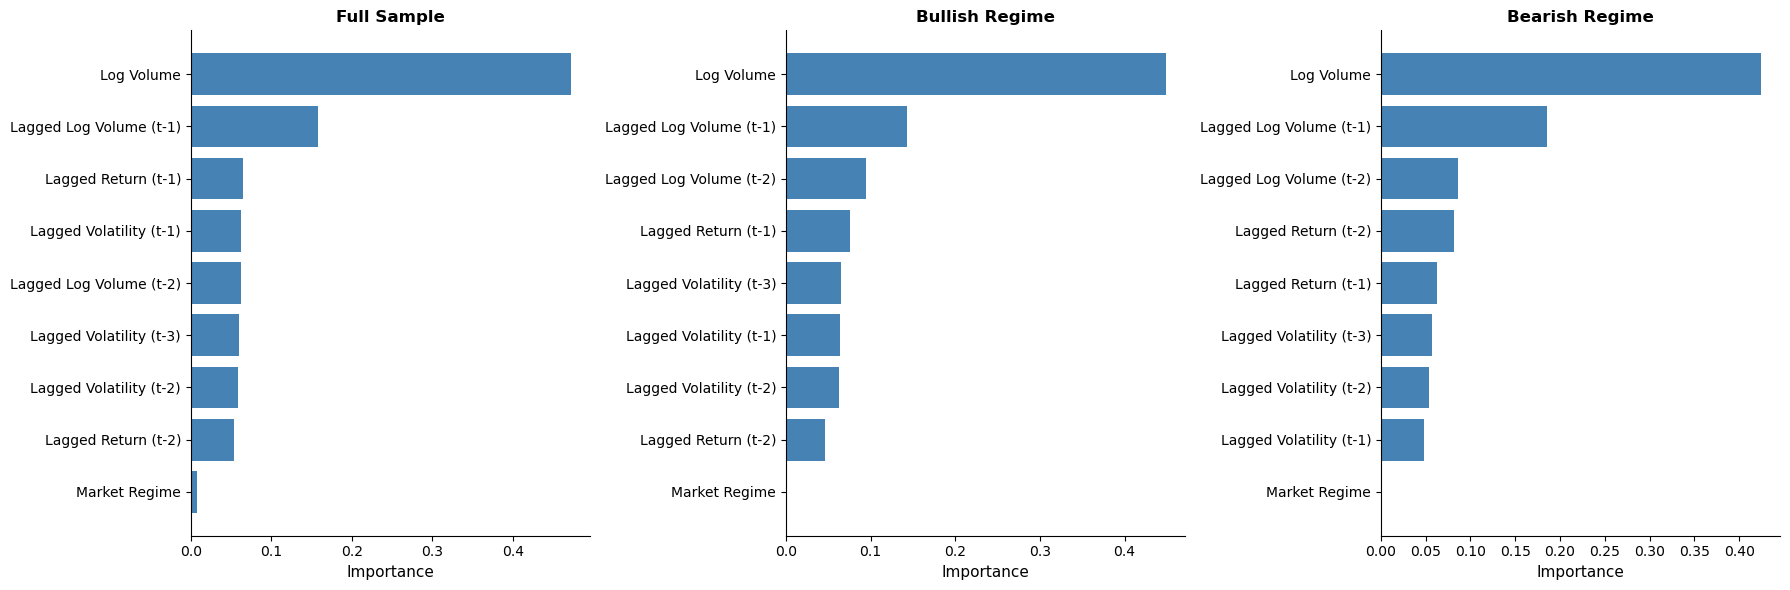

Clean plot saved as RF_feature_importance_clean.png


In [8]:
# CELL 7: Feature Importance Plot — Clean Version
feature_names_clean = {
    'log_volume': 'Log Volume',
    'lvol_lag1': 'Lagged Log Volume (t-1)',
    'lvol_lag2': 'Lagged Log Volume (t-2)',
    'lvol_lag3': 'Lagged Log Volume (t-3)',
    'vol_lag1': 'Lagged Volatility (t-1)',
    'vol_lag2': 'Lagged Volatility (t-2)',
    'vol_lag3': 'Lagged Volatility (t-3)',
    'ret_lag1': 'Lagged Return (t-1)',
    'ret_lag2': 'Lagged Return (t-2)',
    'regime': 'Market Regime'
}

imp_full = pd.DataFrame({
    'Feature': features,
    'Importance': rf_full.feature_importances_
}).sort_values('Importance', ascending=True)

imp_full['Feature'] = imp_full['Feature'].map(feature_names_clean)
imp_bull_plot = imp_bull.sort_values('Importance', ascending=True).copy()
imp_bull_plot['Feature'] = imp_bull_plot['Feature'].map(feature_names_clean)
imp_bear_plot = imp_bear.sort_values('Importance', ascending=True).copy()
imp_bear_plot['Feature'] = imp_bear_plot['Feature'].map(feature_names_clean)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, imp_df, title in zip(
        axes,
        [imp_full, imp_bull_plot, imp_bear_plot],
        ['Full Sample', 'Bullish Regime', 'Bearish Regime']):
    ax.barh(imp_df['Feature'], imp_df['Importance'], color='steelblue')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Importance', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('RF_feature_importance_clean.png', dpi=300, bbox_inches='tight')
plt.show()
print('Clean plot saved as RF_feature_importance_clean.png')

In [9]:
# CELL 8: LSTM — Data preparation
# LSTM requires 3D input: (samples, timesteps, features)
# We use a lookback window of 10 days

LOOKBACK = 10

lstm_features = ['volatility', 'log_volume', 'log_return', 'regime']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_lstm_raw = df[lstm_features].values
y_lstm_raw = df['volatility'].values.reshape(-1, 1)

X_scaled = scaler_X.fit_transform(X_lstm_raw)
y_scaled = scaler_y.fit_transform(y_lstm_raw)

def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i-lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled, LOOKBACK)

split_lstm = int(len(X_seq) * 0.8)
X_tr_lstm, X_te_lstm = X_seq[:split_lstm], X_seq[split_lstm:]
y_tr_lstm, y_te_lstm = y_seq[:split_lstm], y_seq[split_lstm:]

print('LSTM input shape (train):', X_tr_lstm.shape)
print('LSTM input shape (test) :', X_te_lstm.shape)

LSTM input shape (train): (1583, 10, 4)
LSTM input shape (test) : (396, 10, 4)


In [10]:
# CELL 9: LSTM — Model architecture and training
tf.random.set_seed(42)
np.random.seed(42)

model_lstm = Sequential([
    LSTM(64, return_sequences=True,
         input_shape=(LOOKBACK, len(lstm_features))),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse')
model_lstm.summary()

early_stop = EarlyStopping(monitor='val_loss', patience=10,
                            restore_best_weights=True)

history = model_lstm.fit(
    X_tr_lstm, y_tr_lstm,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)

print('\nTraining completed.')
print(f'Best epoch stopped at: {len(history.history["loss"])} epochs')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 10, 64)              │          17,664 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 10, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,625 (119.63 KB)

 Trainable params: 30,625 (119.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0037 - val_loss: 0.0015
Epoch 2/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0030 - val_loss: 0.0012
Epoch 3/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0030 - val_loss: 0.0015
Epoch 4/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0028 - val_loss: 0.0013
Epoch 5/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0028 - val_loss: 0.0013
Epoch 6/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0028 - val_loss: 0.0011
Epoch 7/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0028 - val_loss: 0.0011
Epoch 8/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0028 - val_loss: 0.0013
Epoch 9/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0027 - val_loss: 0.0012
Epoch 10/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0027 - val_loss: 0.0015
Epoch 11/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0027 - val_loss: 0.0010
Epoch 12/100
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0

In [11]:
# CELL 10: LSTM — Evaluation (full sample)
y_pred_lstm_scaled = model_lstm.predict(X_te_lstm)
y_pred_lstm = scaler_y.inverse_transform(y_pred_lstm_scaled)
y_true_lstm = scaler_y.inverse_transform(y_te_lstm)

rmse_lstm = np.sqrt(mean_squared_error(y_true_lstm, y_pred_lstm))
mae_lstm  = mean_absolute_error(y_true_lstm, y_pred_lstm)
r2_lstm   = r2_score(y_true_lstm, y_pred_lstm)

print('========== LSTM — FULL SAMPLE ==========')
print(f'  RMSE : {rmse_lstm:.6f}')
print(f'  MAE  : {mae_lstm:.6f}')
print(f'  R²   : {r2_lstm:.4f}')

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
========== LSTM — FULL SAMPLE ==========
  RMSE : 0.018823
  MAE  : 0.013668
  R²   : -0.0115


In [12]:
# CELL 11: LSTM — Bullish and Bearish evaluation
# Get test set dates and regime labels
test_dates = df['Date'].iloc[LOOKBACK + split_lstm:].reset_index(drop=True)
test_regime = df['regime'].iloc[LOOKBACK + split_lstm:].reset_index(drop=True)

# Align lengths
min_len = min(len(y_true_lstm), len(test_regime))
y_true_flat = y_true_lstm[:min_len].flatten()
y_pred_flat = y_pred_lstm[:min_len].flatten()
regime_flat = test_regime[:min_len].values

def lstm_regime_metrics(y_true, y_pred, regime, label):
    mask = regime == (1 if label == 'BULLISH' else 0)
    yt = y_true[mask]
    yp = y_pred[mask]
    if len(yt) < 5:
        print(f'Not enough {label} observations in test set.')
        return
    rmse = np.sqrt(mean_squared_error(yt, yp))
    mae  = mean_absolute_error(yt, yp)
    r2   = r2_score(yt, yp)
    print(f'\n========== LSTM — {label} ==========')
    print(f'  N (test) : {mask.sum()}')
    print(f'  RMSE : {rmse:.6f}')
    print(f'  MAE  : {mae:.6f}')
    print(f'  R²   : {r2:.4f}')

lstm_regime_metrics(y_true_flat, y_pred_flat, regime_flat, 'BULLISH')
lstm_regime_metrics(y_true_flat, y_pred_flat, regime_flat, 'BEARISH')


========== LSTM — BULLISH ==========
  N (test) : 323
  RMSE : 0.018868
  MAE  : 0.013710
  R²   : -0.0139

========== LSTM — BEARISH ==========
  N (test) : 73
  RMSE : 0.018623
  MAE  : 0.013481
  R²   : -0.0017


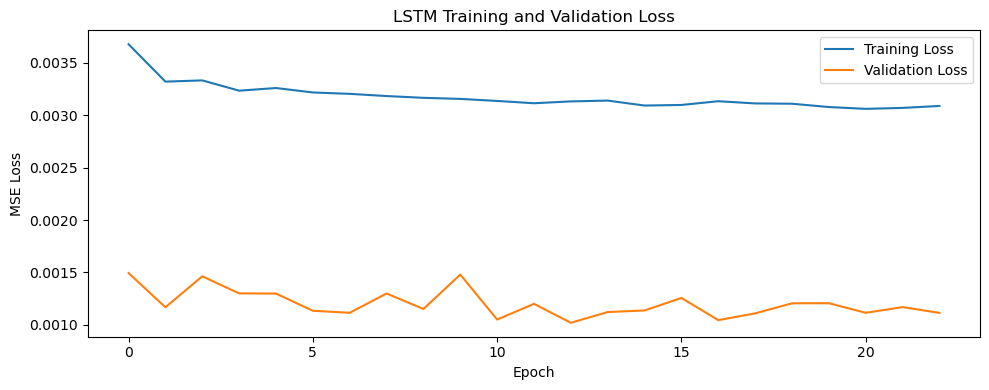

Plot saved as LSTM_training_loss.png


In [13]:
# CELL 12: Training loss plot
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.tight_layout()
plt.savefig('LSTM_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as LSTM_training_loss.png')

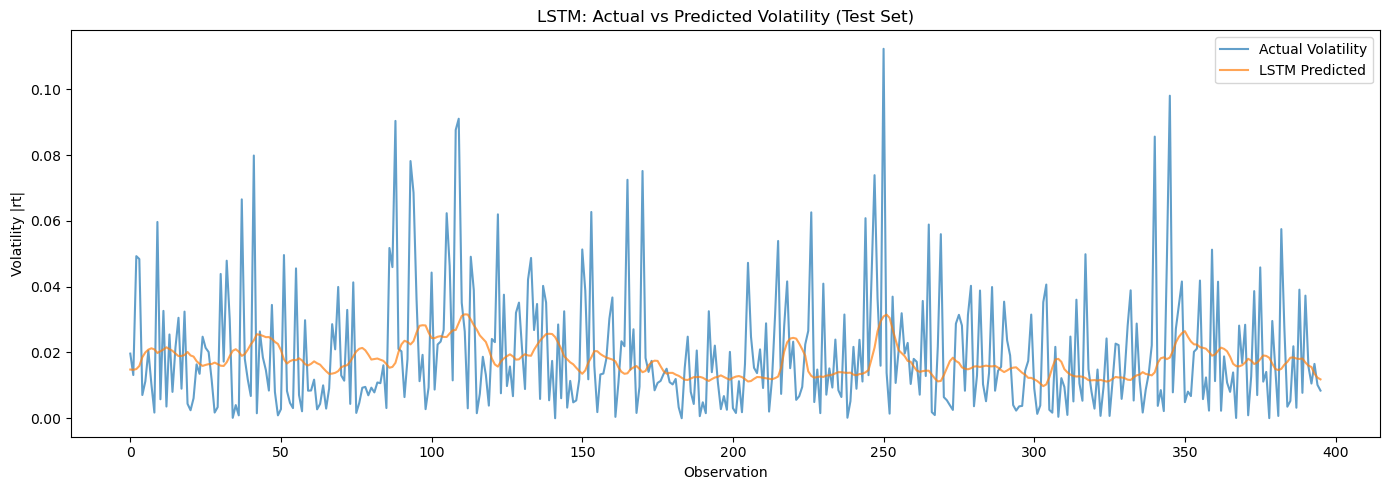

Plot saved as LSTM_actual_vs_predicted.png


In [14]:
# CELL 13: Actual vs Predicted plot — LSTM

plt.figure(figsize=(14, 5))
plt.plot(y_true_flat, label='Actual Volatility', alpha=0.7)
plt.plot(y_pred_flat, label='LSTM Predicted', alpha=0.7)
plt.title('LSTM: Actual vs Predicted Volatility (Test Set)')
plt.xlabel('Observation')
plt.ylabel('Volatility |rt|')
plt.legend()
plt.tight_layout()
plt.savefig('LSTM_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved as LSTM_actual_vs_predicted.png')

In [15]:
# CELL 14: SUMMARY TABLE — All models
summary = pd.DataFrame({
    'Model': ['Random Forest', 'Random Forest', 'Random Forest',
              'LSTM',          'LSTM',          'LSTM'],
    'Sample': ['Full', 'Bullish', 'Bearish',
               'Full', 'Bullish', 'Bearish'],
    'RMSE': [rmse_rf_full, rmse_bull, rmse_bear,
             rmse_lstm, None, None],
    'MAE':  [mae_rf_full,  mae_bull,  mae_bear,
             mae_lstm,  None, None],
    'R2':   [r2_rf_full,   r2_bull,   r2_bear,
             r2_lstm,   None, None]
})

# Fill LSTM regime values
for regime_label, regime_val in [('Bullish', 1), ('Bearish', 0)]:
    mask = regime_flat == regime_val
    yt = y_true_flat[mask]
    yp = y_pred_flat[mask]
    if len(yt) >= 5:
        rmse_r = np.sqrt(mean_squared_error(yt, yp))
        mae_r  = mean_absolute_error(yt, yp)
        r2_r   = r2_score(yt, yp)
        idx = summary[(summary['Model'] == 'LSTM') &
                      (summary['Sample'] == regime_label)].index
        summary.loc[idx, 'RMSE'] = rmse_r
        summary.loc[idx, 'MAE']  = mae_r
        summary.loc[idx, 'R2']   = r2_r

summary['RMSE'] = summary['RMSE'].map(lambda x: f'{x:.6f}' if x is not None else 'N/A')
summary['MAE']  = summary['MAE'].map(lambda x: f'{x:.6f}' if x is not None else 'N/A')
summary['R2']   = summary['R2'].map(lambda x: f'{x:.4f}' if x is not None else 'N/A')

print('\n========== FINAL SUMMARY TABLE ==========')
print(summary.to_string(index=False))

summary.to_csv('ML_results_summary.csv', index=False)
print('\nSummary saved as ML_results_summary.csv')
print('\n========== PYTHON CODE COMPLETED SUCCESSFULLY ==========')


========== FINAL SUMMARY TABLE ==========
        Model  Sample     RMSE      MAE      R2
Random Forest    Full 0.015875 0.011299  0.2784
Random Forest Bullish 0.015568 0.010945  0.3483
Random Forest Bearish 0.016164 0.011910  0.0425
         LSTM    Full 0.018823 0.013668 -0.0115
         LSTM Bullish 0.018868 0.013710 -0.0139
         LSTM Bearish 0.018623 0.013481 -0.0017

Summary saved as ML_results_summary.csv

========== PYTHON CODE COMPLETED SUCCESSFULLY ==========
